DATA COLLECTION
1. Importing required Libraries for EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

2. Loading CSV data as Pandas DataFrame

In [4]:
df=pd.read_csv('data_set.csv')

3. Types of variables

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18434 entries, 0 to 18433
Columns: 141 entries, uniqueid to adblue_level
dtypes: float64(122), int64(13), object(6)
memory usage: 19.8+ MB


In [7]:
num=[feature for feature in df.columns if df[feature].dtype=='int64' or df[feature].dtype=='float64']
print('We have {} numerical features: {}'.format(len(num), num))
cat=[feature for feature in df.columns if df[feature].dtype=='object']
print('\nWe have {} categorical features: {}'.format(len(cat), cat))

We have 135 numerical features: ['ts', 'lat', 'lng', 'external_bat_voltage', 'internal_bat_voltage', 'engineload', 'tanklevel', 'throttle', 'coolant', 'intakeairtemp', 'engineoiltemp', 'imap', 'vehiclespeed', 'warmups', 'rpm', 'obddistance', 'maf', 'fuelrail', 'runtime', 'mil', 'obdstandards', 'telltale', 'pto_drive_engagement', 'engine_torque_percent', 'service_distance', 'gross_combination_vehicle_weight', 'selected_gear', 'current_gear', 'fuel_consumption', 'fuel_level', 'fl_level', 'fuel_rate', 'fuel_economy', 'accelerator_pedal_pos', 'vehicle_weight', 'air_suspension_pressure_front_axle_left', 'air_suspension_pressure_front_axle_right', 'air_suspension_pressure_rear_axle_left', 'air_suspension_pressure_rear_axle_right', 'state_of_charge', 'battery_pack_voltage', 'battery_pack_current', 'power', 'lamp_status', 'hydraulic_oil_filter', 'air_filter', 'no_charging', 'low_fuel', 'engine_temp_high', 'hydraulic_oil_temp_high', 'water_in_fuel', 'low_oil_pressure', 'roller_speed', 'vibratio

4. Number of Rows and Columns respectively

In [9]:
df.shape

(18434, 141)

5. Show top 5 records

In [11]:
df.head()

,uniqueid,ts,lat,lng,external_bat_voltage,internal_bat_voltage,engineload,tanklevel,throttle,coolant,...,live_location,to_be_expired_at,status,event_id,particulated_trap_inlet_pressure,boost_pressure,intake_manifold_1_temperature,air_inlet_pressure,exhaust_gas_temperature,adblue_level
0,it_220403501,1709340731,19.069340,78.355148,NaN,NaN,28,NaN,NaN,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,it_220403501,1709340794,19.069347,78.355141,NaN,NaN,22,NaN,NaN,41,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,it_220403501,1709340857,19.069414,78.355179,NaN,NaN,25,NaN,NaN,48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,it_220403501,1709340920,19.069258,78.355225,NaN,NaN,35,NaN,NaN,52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,it_220403501,1709340983,19.069094,78.355339,NaN,NaN,0,NaN,NaN,57,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


DATA CLEANING
1. Removing unnecessary features from dataset

In [13]:
# Drop columns with all NaN values
df_cleaned = df.dropna(axis=1, how='all')
# Drop columns with the same value
df_cleaned = df_cleaned.loc[:, df_cleaned.nunique() > 1]

num=[feature for feature in df_cleaned.columns if df_cleaned[feature].dtype=='int64' or df_cleaned[feature].dtype=='float64']
print('We have {} numerical features: {}'.format(len(num), num))
cat=[feature for feature in df_cleaned.columns if df_cleaned[feature].dtype=='object']
print('\nWe have {} categorical features: {}'.format(len(cat), cat))

We have 21 numerical features: ['ts', 'lat', 'lng', 'engineload', 'coolant', 'vehiclespeed', 'rpm', 'obddistance', 'runtime', 'engine_torque_percent', 'current_gear', 'fuel_consumption', 'fuel_level', 'fl_level', 'fuel_rate', 'fuel_economy', 'accelerator_pedal_pos', 'engine_throttle_valve1_pos', 'drivers_demand_engine_torque_percent', 'engine_torque_mode', 'adblue_level']

We have 5 categorical features: ['pluscode', 'can_raw_data', 'brake_switch_status', 'clutch_switch_status', 'parking_switch_status']


In [14]:
df_cleaned.head()

,ts,lat,lng,engineload,coolant,vehiclespeed,rpm,obddistance,runtime,engine_torque_percent,...,accelerator_pedal_pos,pluscode,can_raw_data,engine_throttle_valve1_pos,drivers_demand_engine_torque_percent,engine_torque_mode,brake_switch_status,clutch_switch_status,parking_switch_status,adblue_level
0,1709340731,19.069340,78.355148,28,33,0.00000,749.000,60780800,1970.85,21,...,0.0,7JFW3994+,"0CF00300:D1001CFFFF4C4886,0CF00400:407D9268170...",100.0,0,1,Released,Released,Pressed,NaN
1,1709340794,19.069347,78.355141,22,41,0.00000,1208.375,60780800,1970.85,18,...,23.6,7JFW3994+,"0CF00300:D03B16FFFF4C4283,0CF00400:41908FC3250...",99.6,19,2,Released,Pressed,Pressed,NaN
2,1709340857,19.069414,78.355179,25,48,1.40625,752.625,60780800,1970.85,18,...,0.0,7JFW3994+,"0CF00300:D10019FFFF4C4983,0CF00400:307D8F85170...",99.6,0,1,Pressed,Pressed,Released,NaN
3,1709340920,19.069258,78.355225,35,52,2.81250,996.375,60780820,1970.90,27,...,33.6,7JFW3994+,"0CF00300:D05423FFFF4C4C82,0CF00400:519998231F0...",99.6,28,2,Released,Pressed,Released,NaN
4,1709340983,19.069094,78.355339,0,57,4.53125,1065.750,60780840,1970.90,1,...,3.2,7JFW3994+,"0CF00300:D10800FFFF4C3284,0CF00400:017E7E4E210...",100.0,1,2,Released,Pressed,Released,NaN


In [15]:
df_cleaned.drop_duplicates()
df_cleaned.shape

(18434, 26)

In [16]:
df_cleaned.isnull().sum()

ts                                         0
lat                                        0
lng                                        0
engineload                                 0
coolant                                    0
vehiclespeed                               0
rpm                                        0
obddistance                                0
runtime                                   14
engine_torque_percent                      0
current_gear                               0
fuel_consumption                           0
fuel_level                                 2
fl_level                                   0
fuel_rate                                  0
fuel_economy                               0
accelerator_pedal_pos                      0
pluscode                                   0
can_raw_data                               0
engine_throttle_valve1_pos                 0
drivers_demand_engine_torque_percent       0
engine_torque_mode                         0
brake_swit

In [17]:
df_cleaned['runtime'].mode()[0]

2260.25

In [18]:
df_cleaned['runtime']=df_cleaned['runtime'].fillna(df_cleaned['runtime'].mode()[0])
df_cleaned['fuel_level']=df_cleaned['fuel_level'].fillna(df_cleaned['fuel_level'].mode()[0])
df_cleaned['adblue_level']=df_cleaned['adblue_level'].fillna(df_cleaned['adblue_level'].mode()[0])

In [19]:
df_cleaned.isnull().sum()

ts                                      0
lat                                     0
lng                                     0
engineload                              0
coolant                                 0
vehiclespeed                            0
rpm                                     0
obddistance                             0
runtime                                 0
engine_torque_percent                   0
current_gear                            0
fuel_consumption                        0
fuel_level                              0
fl_level                                0
fuel_rate                               0
fuel_economy                            0
accelerator_pedal_pos                   0
pluscode                                0
can_raw_data                            0
engine_throttle_valve1_pos              0
drivers_demand_engine_torque_percent    0
engine_torque_mode                      0
brake_switch_status                     0
clutch_switch_status              

In [20]:
df_cleaned.head()

,ts,lat,lng,engineload,coolant,vehiclespeed,rpm,obddistance,runtime,engine_torque_percent,...,accelerator_pedal_pos,pluscode,can_raw_data,engine_throttle_valve1_pos,drivers_demand_engine_torque_percent,engine_torque_mode,brake_switch_status,clutch_switch_status,parking_switch_status,adblue_level
0,1709340731,19.069340,78.355148,28,33,0.00000,749.000,60780800,1970.85,21,...,0.0,7JFW3994+,"0CF00300:D1001CFFFF4C4886,0CF00400:407D9268170...",100.0,0,1,Released,Released,Pressed,100.0
1,1709340794,19.069347,78.355141,22,41,0.00000,1208.375,60780800,1970.85,18,...,23.6,7JFW3994+,"0CF00300:D03B16FFFF4C4283,0CF00400:41908FC3250...",99.6,19,2,Released,Pressed,Pressed,100.0
2,1709340857,19.069414,78.355179,25,48,1.40625,752.625,60780800,1970.85,18,...,0.0,7JFW3994+,"0CF00300:D10019FFFF4C4983,0CF00400:307D8F85170...",99.6,0,1,Pressed,Pressed,Released,100.0
3,1709340920,19.069258,78.355225,35,52,2.81250,996.375,60780820,1970.90,27,...,33.6,7JFW3994+,"0CF00300:D05423FFFF4C4C82,0CF00400:519998231F0...",99.6,28,2,Released,Pressed,Released,100.0
4,1709340983,19.069094,78.355339,0,57,4.53125,1065.750,60780840,1970.90,1,...,3.2,7JFW3994+,"0CF00300:D10800FFFF4C3284,0CF00400:017E7E4E210...",100.0,1,2,Released,Pressed,Released,100.0


2. Converting all binary data into integer value

In [22]:
print(len(df_cleaned['brake_switch_status'].unique()))
print(len(df_cleaned['clutch_switch_status'].unique()))
print(len(df_cleaned['parking_switch_status'].unique()))

print(len(df_cleaned['pluscode'].unique()))
print(len(df_cleaned['can_raw_data'].unique()))

2
2
2
2639
17874


In [23]:
df_2=df_cleaned.copy()
df_cleaned['brake_switch_status']=df_cleaned['brake_switch_status'].map({'Pressed':0,'Released':1})
df_cleaned['clutch_switch_status']=df_cleaned['clutch_switch_status'].map({'Pressed':0,'Released':1})
df_cleaned['parking_switch_status']=df_cleaned['parking_switch_status'].map({'Pressed':0,'Released':1})

UNIVARIATE ANALYSIS
1. Numerical Data
I. Plotting Kernel Density Estimate plot

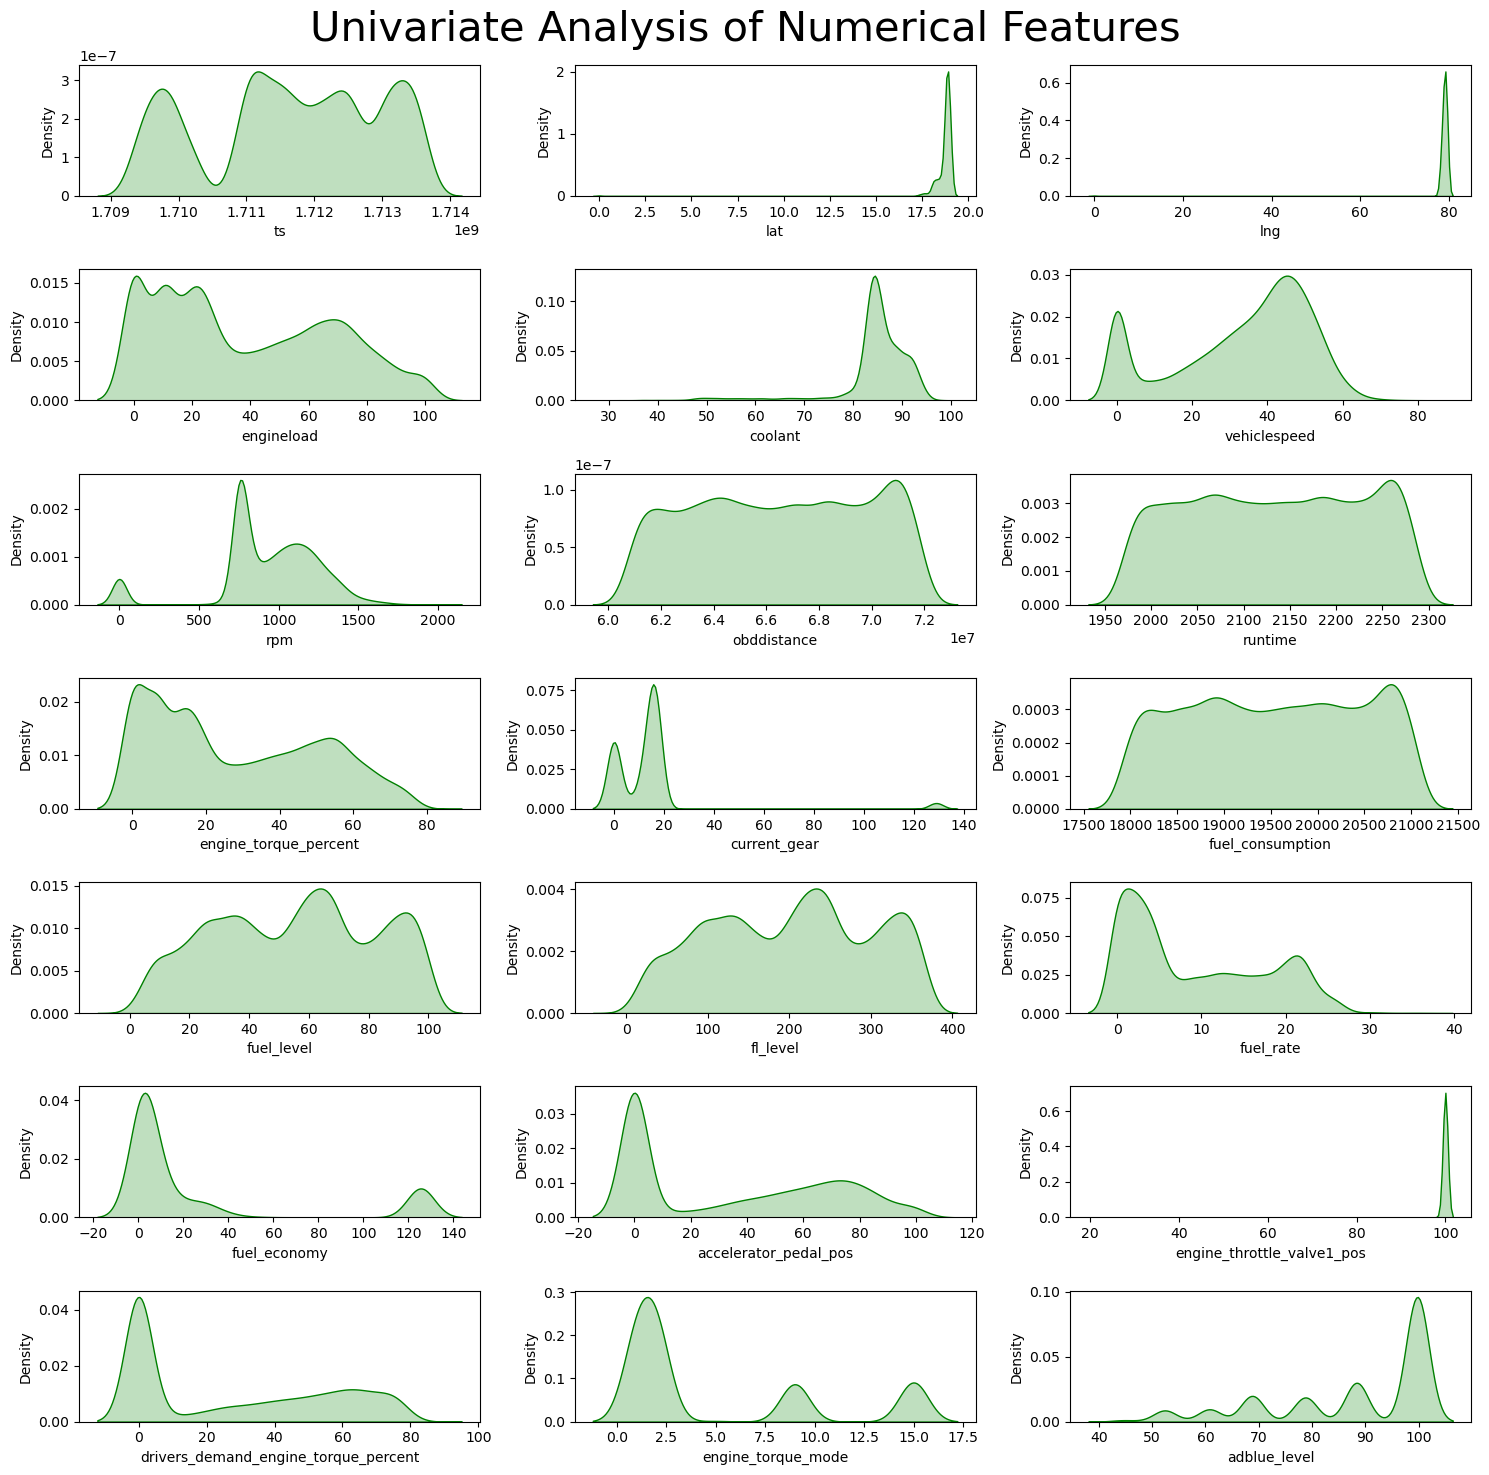

In [25]:
plt.figure(figsize=(15,15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=30, fontweight=10)
for i in range(0, len(num)):
    plt.subplot(7,3,i+1)
    sns.kdeplot(x=df_2[num[i]],shade=True,color='g')
    plt.xlabel(num[i])
    plt.tight_layout()

Observations-1:
1. runtime, fuel_consumption and obddistance has similar graphs and can be combined to form a new single feature mileage which is similar to fuel_economy.
2. drivers_demand_engine_torque_percent and accelerator_pedal_pos has similar graphs and can be combined to form a new feature driver_input_demand
3. fuel_level and fl_level are same thing and one can be omitted
4. engine_torque_percent and engineload has similar graphs and can be combined to form a new feature performance_demand

II. Plotting Scatter plot

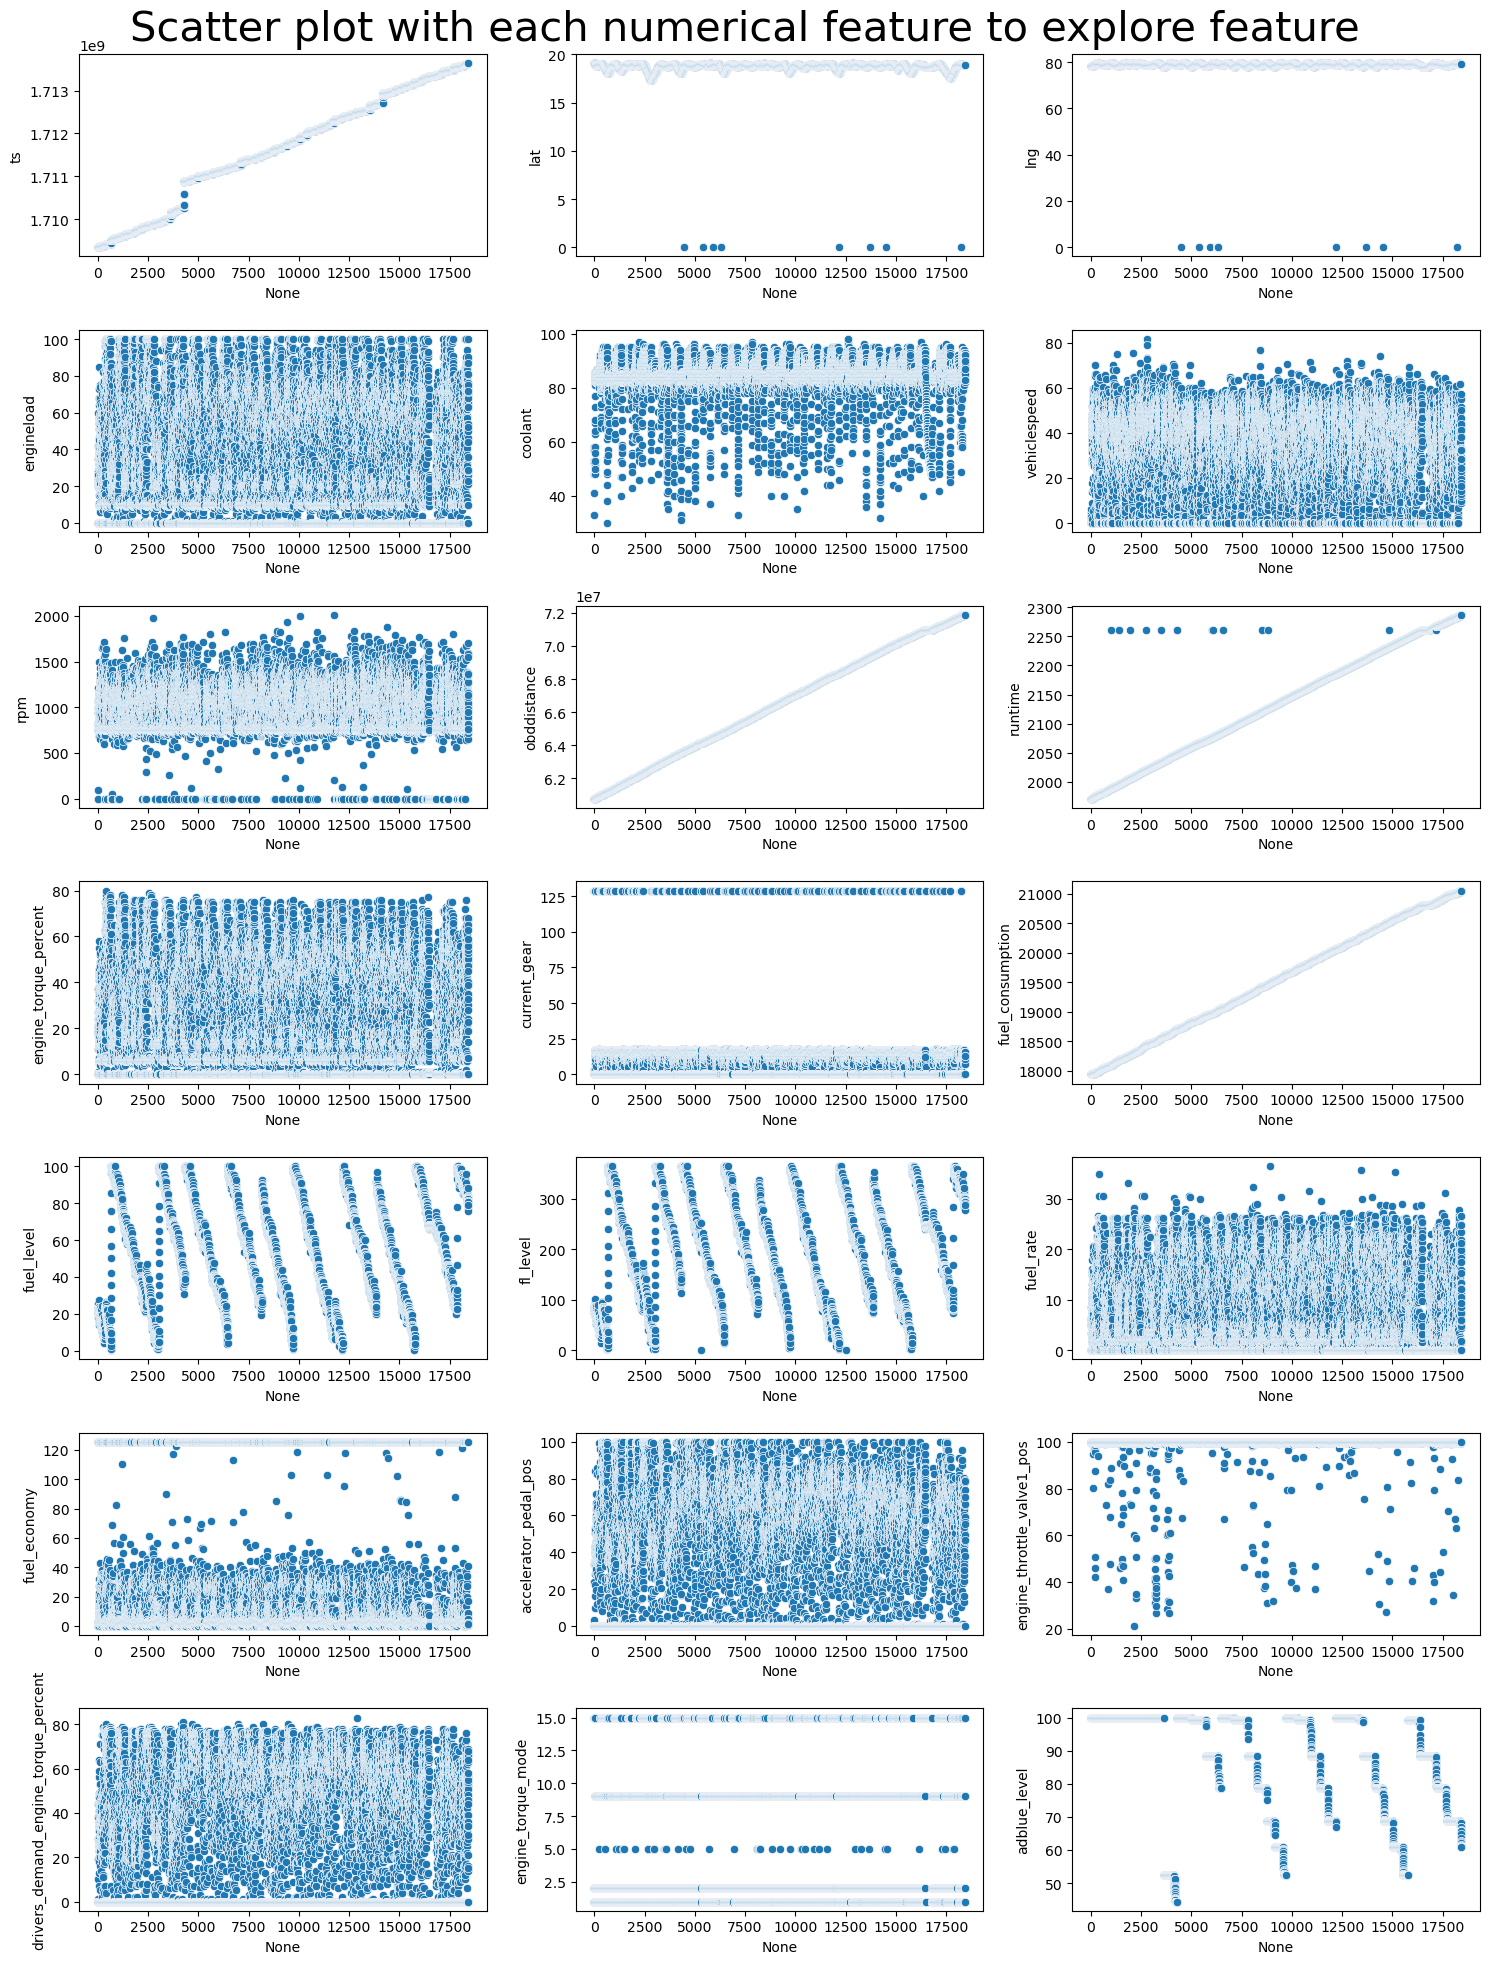

In [27]:
plt.figure(figsize=(15,20))
plt.suptitle('Scatter plot with each numerical feature to explore feature', fontsize=30, fontweight=10)
for i in range(0, len(num)):
    plt.subplot(7,3,i+1)
    sns.scatterplot(y=num[i],x=df_2.index, data=df_2)
    plt.tight_layout()

2. Categorical Data
I. Plotting Count plot

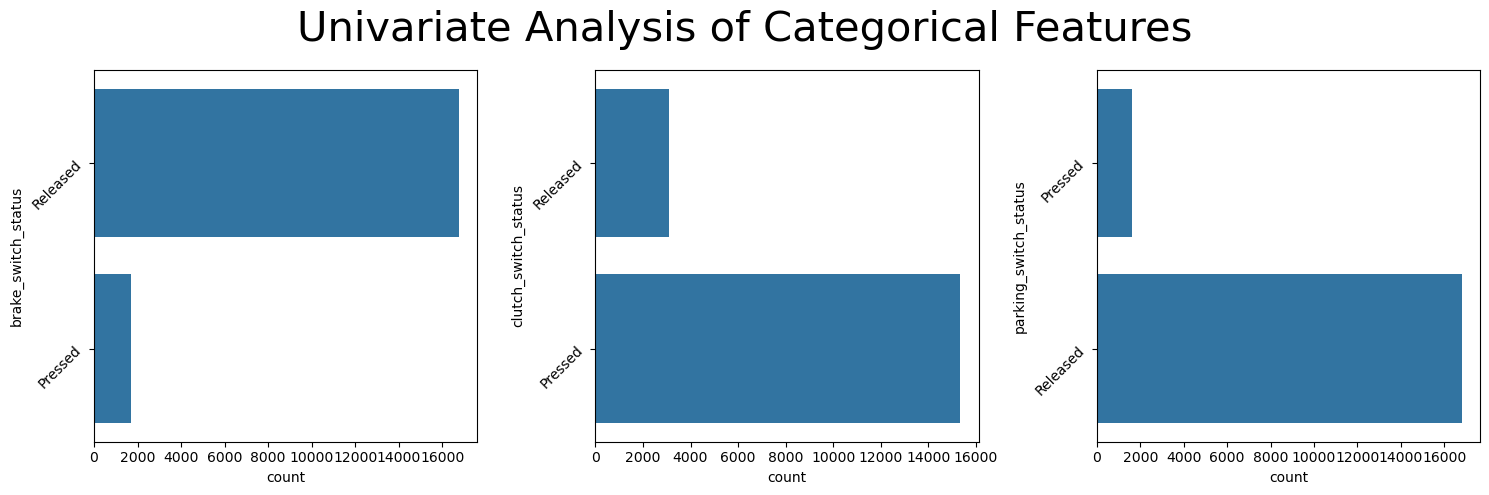

In [29]:
plt.figure(figsize=(15,5))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=30, fontweight=10)
cat1=['brake_switch_status', 'clutch_switch_status', 'parking_switch_status']
for i in range(0, len(cat1)):
    plt.subplot(1,3,i+1)
    sns.countplot(y=df_2[cat1[i]])
    plt.ylabel(cat1[i])
    plt.yticks(rotation=45)
    plt.tight_layout()

Observations-2:
1. brake_switch_status is mostly released
2. clutch_switch_status is mostly pressed
3. parking_switch_status is mostly released

BIVARIATE ANALYSIS
1. Plotting Heatmap

In [31]:
col=['can_raw_data','pluscode','parking_switch_status','clutch_switch_status','brake_switch_status'] #Deleting all categorical data
for col1 in col:
    del df_2[col1]

In [32]:
df_corr=df_2.corr() #correlation matrix

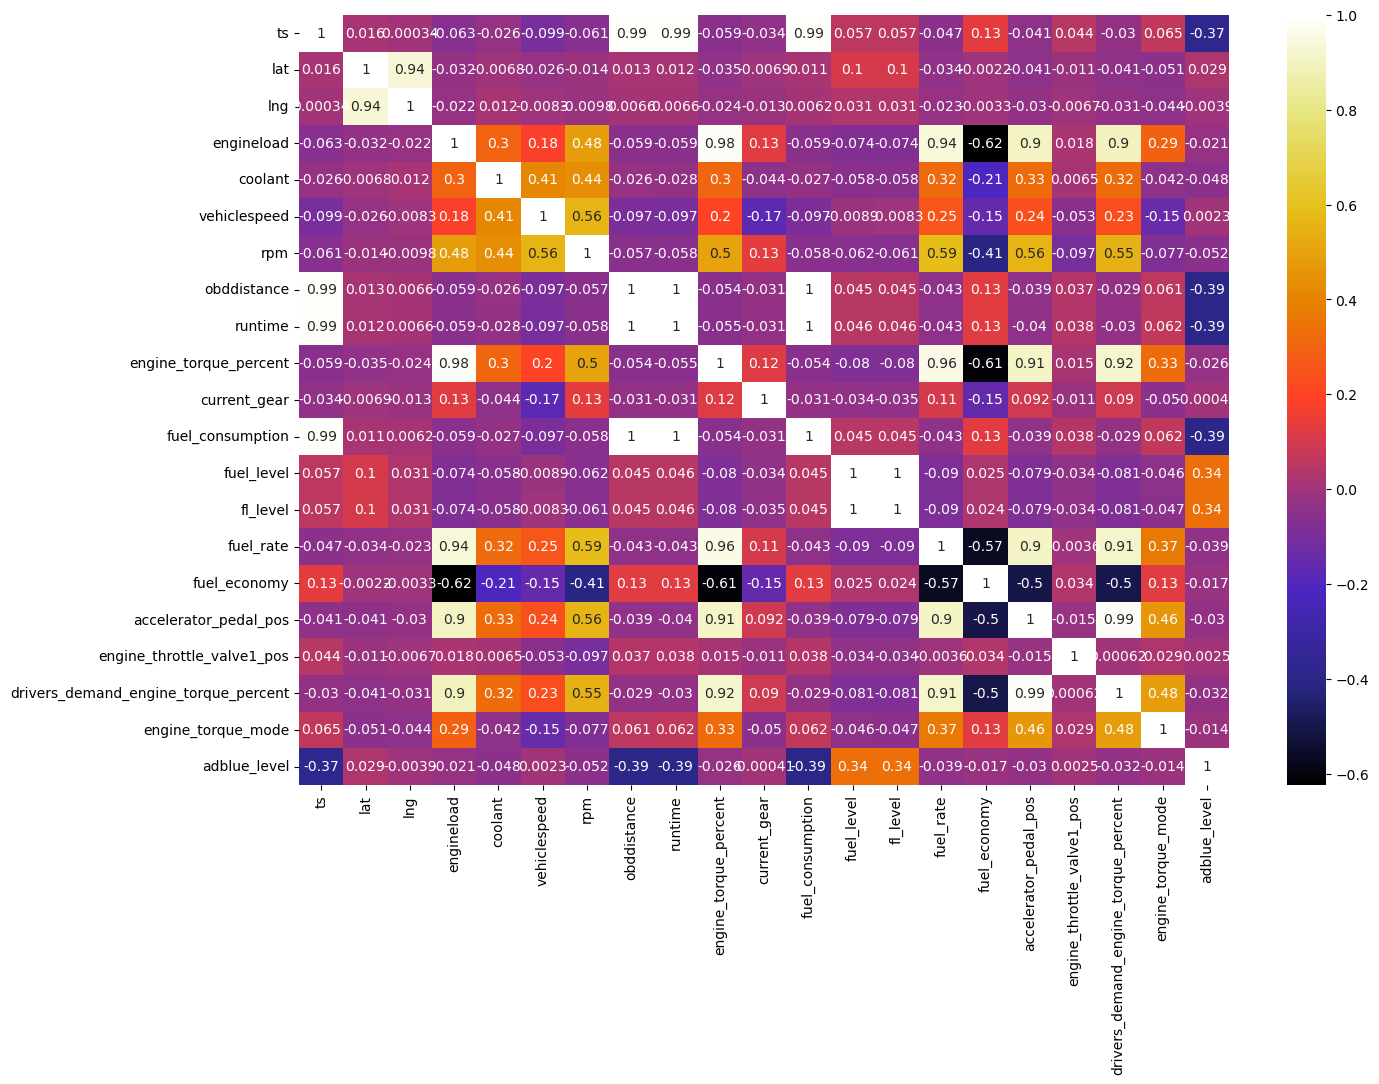

In [33]:
plt.figure(figsize=(15,10))
sns.heatmap(df_corr, cmap="CMRmap", annot=True) #plotting heatmap
plt.show()

In [34]:
mask = np.tril(np.ones_like(np.abs(df_corr), dtype=bool), k=-1) #masking lower triangle of the matrix
df_pairs = df_corr.where(mask & (np.abs(df_corr) > 0.4)).stack() #forming pairs having absolute value of Correlation coefficient greater than 0.4
pairs_with_corr = df_pairs.reset_index()
pairs_with_corr.columns = ['Feature1', 'Feature2', 'Correlation']
pairs_with_corr

,Feature1,Feature2,Correlation
0,lng,lat,0.935495
1,vehiclespeed,coolant,0.412702
2,rpm,engineload,0.482889
3,rpm,coolant,0.435605
4,rpm,vehiclespeed,0.559204
5,obddistance,ts,0.993215
6,runtime,ts,0.991354
7,runtime,obddistance,0.998241
8,engine_torque_percent,engineload,0.982212
9,engine_torque_percent,rpm,0.504514


2. Plotting boxplot

In [36]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df_scaled=scaler.fit_transform(df_2)
normalized_df = pd.DataFrame(df_scaled, columns=df_2.columns) #scaling data

(array([-30., -25., -20., -15., -10.,  -5.,   0.,   5.,  10.]),
 [Text(-30.0, 0, '−30'),
  Text(-25.0, 0, '−25'),
  Text(-20.0, 0, '−20'),
  Text(-15.0, 0, '−15'),
  Text(-10.0, 0, '−10'),
  Text(-5.0, 0, '−5'),
  Text(0.0, 0, '0'),
  Text(5.0, 0, '5'),
  Text(10.0, 0, '10')])

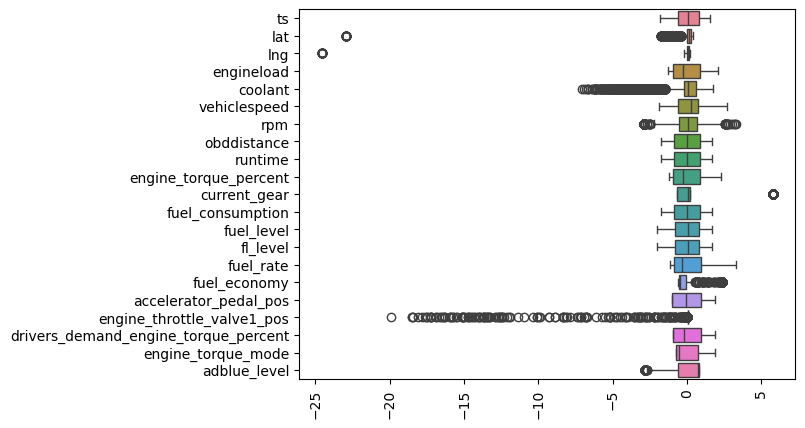

In [37]:
sns.boxplot(data= normalized_df, orient="h")
plt.xticks(rotation=90)

Vehicle Performance
1. Plotting graph between Vehicle speed and Fuel economy

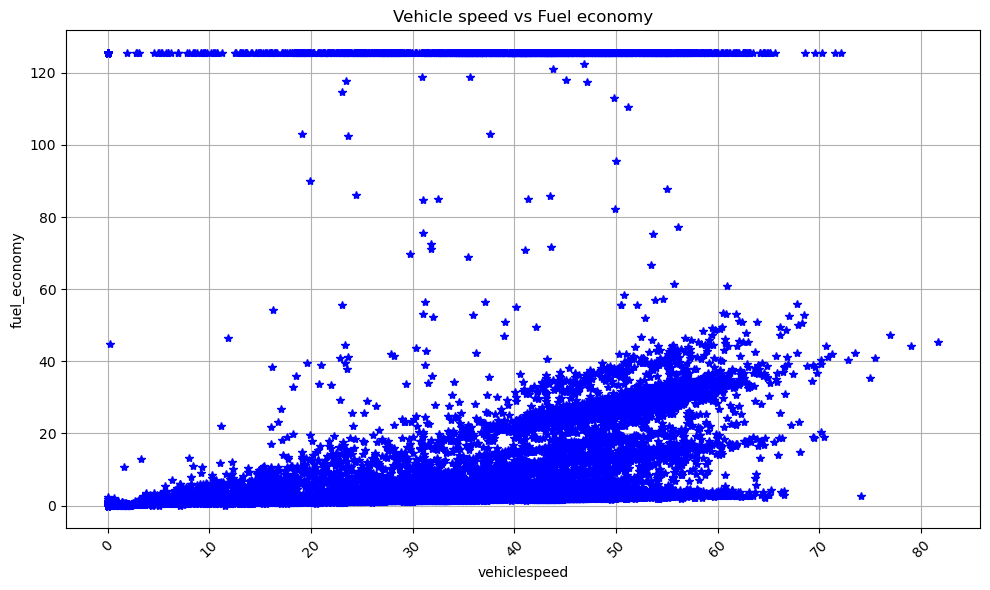

In [39]:
plt.figure(figsize=(10, 6))
plt.plot(df_2['vehiclespeed'], df_2['fuel_economy'], marker='*', linestyle=' ', color='b')
plt.title('Vehicle speed vs Fuel economy')
plt.xlabel('vehiclespeed')
plt.ylabel('fuel_economy')
plt.grid(True)
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

Observation-3:
1. The graph shows there are 2 groups of data, so we need to separate them into 2 groups and then analyse

In [41]:
from sklearn.cluster import KMeans
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_2[['fuel_economy','vehiclespeed']])
k_means = KMeans(n_clusters=2, random_state=0)
pred=k_means.fit(scaled_data)
df_2['Cluster'] = pred.labels_ #clustered into 2 groups and added the column to the dataframe
df_2.head() #view first 5 rows

,ts,lat,lng,engineload,coolant,vehiclespeed,rpm,obddistance,runtime,engine_torque_percent,...,fuel_level,fl_level,fuel_rate,fuel_economy,accelerator_pedal_pos,engine_throttle_valve1_pos,drivers_demand_engine_torque_percent,engine_torque_mode,adblue_level,Cluster
0,1709340731,19.069340,78.355148,28,33,0.00000,749.000,60780800,1970.85,21,...,23.6,86.14,5.30,0.000000,0.0,100.0,0,1,100.0,1
1,1709340794,19.069347,78.355141,22,41,0.00000,1208.375,60780800,1970.85,18,...,23.6,86.14,6.45,0.000000,23.6,99.6,19,2,100.0,1
2,1709340857,19.069414,78.355179,25,48,1.40625,752.625,60780800,1970.85,18,...,22.8,83.22,4.70,0.337891,0.0,99.6,0,1,100.0,1
3,1709340920,19.069258,78.355225,35,52,2.81250,996.375,60780820,1970.90,27,...,20.4,74.46,8.60,0.121094,33.6,99.6,28,2,100.0,1
4,1709340983,19.069094,78.355339,0,57,4.53125,1065.750,60780840,1970.90,1,...,23.2,84.68,0.00,125.500000,3.2,100.0,1,2,100.0,0


In [42]:
df_5=df_2.where(df_2['Cluster']==1).dropna()
del df_5['Cluster'] #extracting the data from the dataframe with cluster value 1(as cluster with value 1 shows a pattern)

In [43]:
from scipy.stats import zscore
z_scores = df_5.apply(zscore)
df_no_o = df_5[(z_scores.abs() < 3).all(axis=1)] #removing outliers using z-score

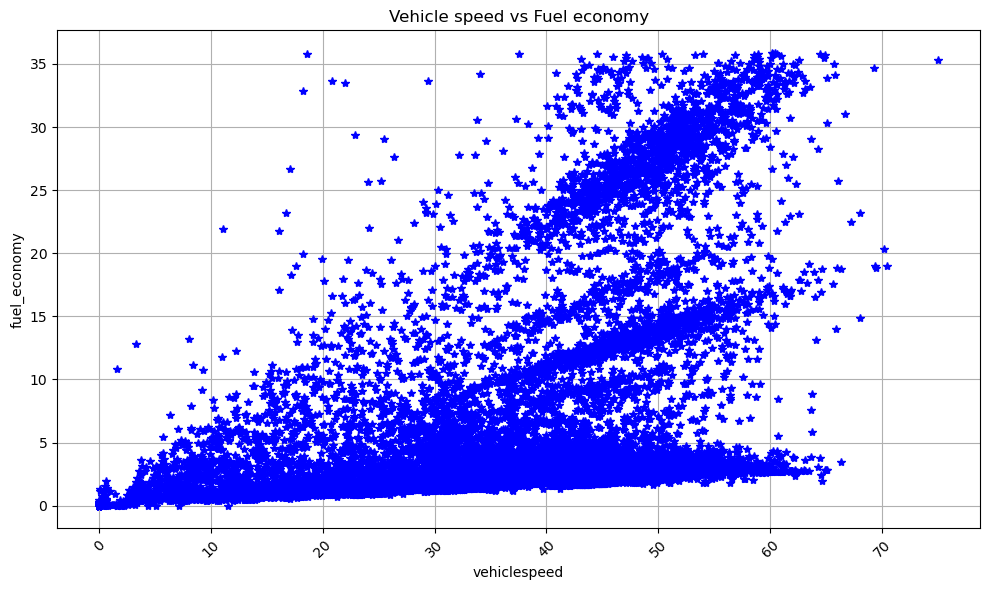

In [44]:
plt.figure(figsize=(10, 6)) #plotting graph for the cluster
plt.plot(df_no_o['vehiclespeed'], df_no_o['fuel_economy'], marker='*', linestyle=' ', color='b')
plt.title('Vehicle speed vs Fuel economy')
plt.xlabel('vehiclespeed')
plt.ylabel('fuel_economy')
plt.grid(True)
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

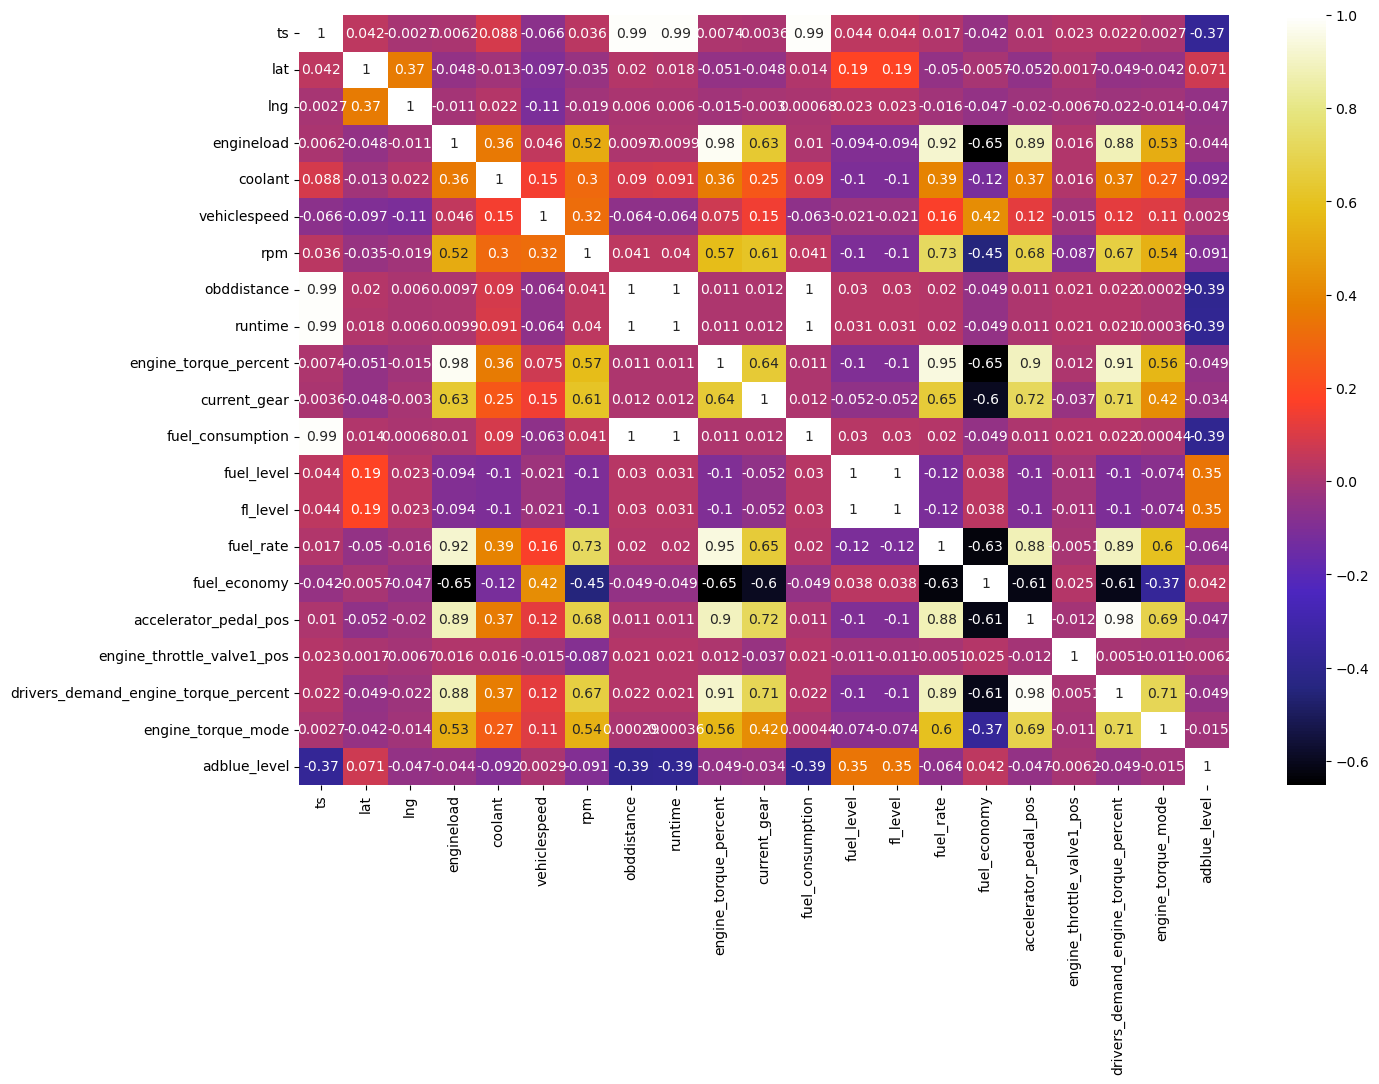

,Feature1,Feature2,Correlation
0,rpm,engineload,0.521584
1,obddistance,ts,0.993079
2,runtime,ts,0.991348
3,runtime,obddistance,0.998434
4,engine_torque_percent,engineload,0.976730
5,engine_torque_percent,rpm,0.574617
6,current_gear,engineload,0.633190
7,current_gear,rpm,0.607759
8,current_gear,engine_torque_percent,0.643763
9,fuel_consumption,ts,0.992851


In [45]:
df_corr=df_no_o.corr() #correlation matrix
plt.figure(figsize=(15,10))
sns.heatmap(df_corr, cmap="CMRmap", annot=True) #plotting heatmap
plt.show()
mask = np.tril(np.ones_like(np.abs(df_corr), dtype=bool), k=-1) #masking lower triangle of the matrix
df_pairs = df_corr.where(mask & (np.abs(df_corr) > 0.4)).stack() #forming pairs having absolute value of Correlation coefficient greater than 0.4
pairs_with_corr = df_pairs.reset_index()
pairs_with_corr.columns = ['Feature1', 'Feature2', 'Correlation']
pairs_with_corr

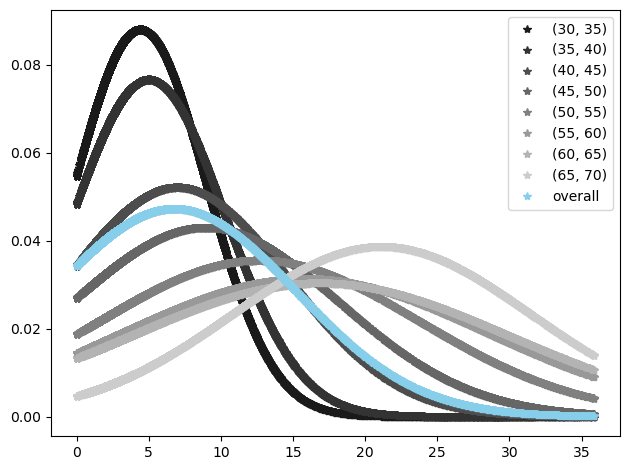

In [46]:
from scipy.stats import norm #plotting normal distribution at different intervals
means=[]
x=df_no_o['fuel_economy']
color=['0.1','0.2','0.3','0.4','0.5','0.6','0.7','0.8']
label=[]
for i in range(0,8):
    label.append((30+5*i,35+5*i))
for i in range(0,8):
    y = df_no_o['fuel_economy'].where((df_no_o['vehiclespeed']>(30+(i*5)))&(df_no_o['vehiclespeed']<(35+(i*5)))).dropna()
    mean, std_dev = norm.fit(y)
    means.append(mean)
    p = (1 / (np.sqrt(2 * np.pi) * std_dev)) * np.exp(-((x - mean)**2) / (2 * std_dev**2))
    plt.plot( x,p, label=label[i], marker='*', linestyle=' ', color=color[i])
mean1, std_dev1 = norm.fit(x)
p1 = (1 / (np.sqrt(2 * np.pi) * std_dev1)) * np.exp(-((x - mean1)**2) / (2 * std_dev1**2))
plt.plot( x,p1, label= 'overall', marker='*', linestyle=' ', color='skyblue')
plt.tight_layout()
plt.legend()
plt.show()

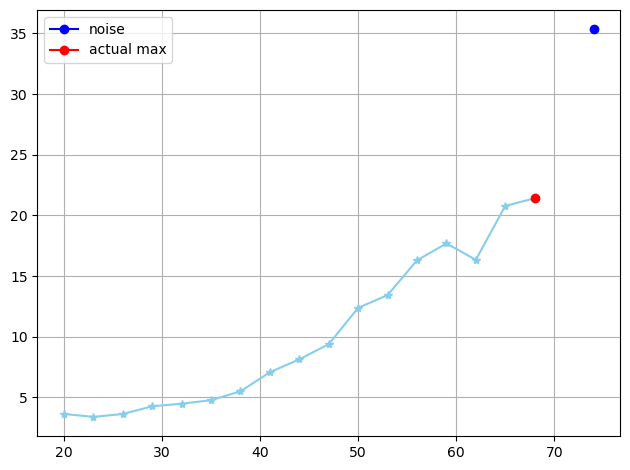

In [47]:
label1=[]
for i in range(0,20):
    label1.append(20+3*i)
means1=[]
for i in range(0,20):
    y = df_no_o['fuel_economy'].where((df_no_o['vehiclespeed']>=(20+3*i))&(df_no_o['vehiclespeed']<(23+3*i))).dropna()
    mean, std_dev = norm.fit(y)
    means1.append(mean)
plt.plot(label1,means1,marker='*',color='skyblue')
a=max(means1)
t=label1[means1.index(a)]
plt.plot(t,a, marker='o',label='noise', color='b')
plt.plot(label1[16],means1[16],label='actual max', marker='o', color='r')
plt.tight_layout()
plt.legend()
plt.grid(True)
plt.show()

Observation-4:
1. Now we find a relation between vehicle speed and fuel economy.
2. As we increase speed, the fuel economy also increases until speed of 70km/h.

Inference:
1. At a speed of 65-70km/h the performance of vehicle is at the highest

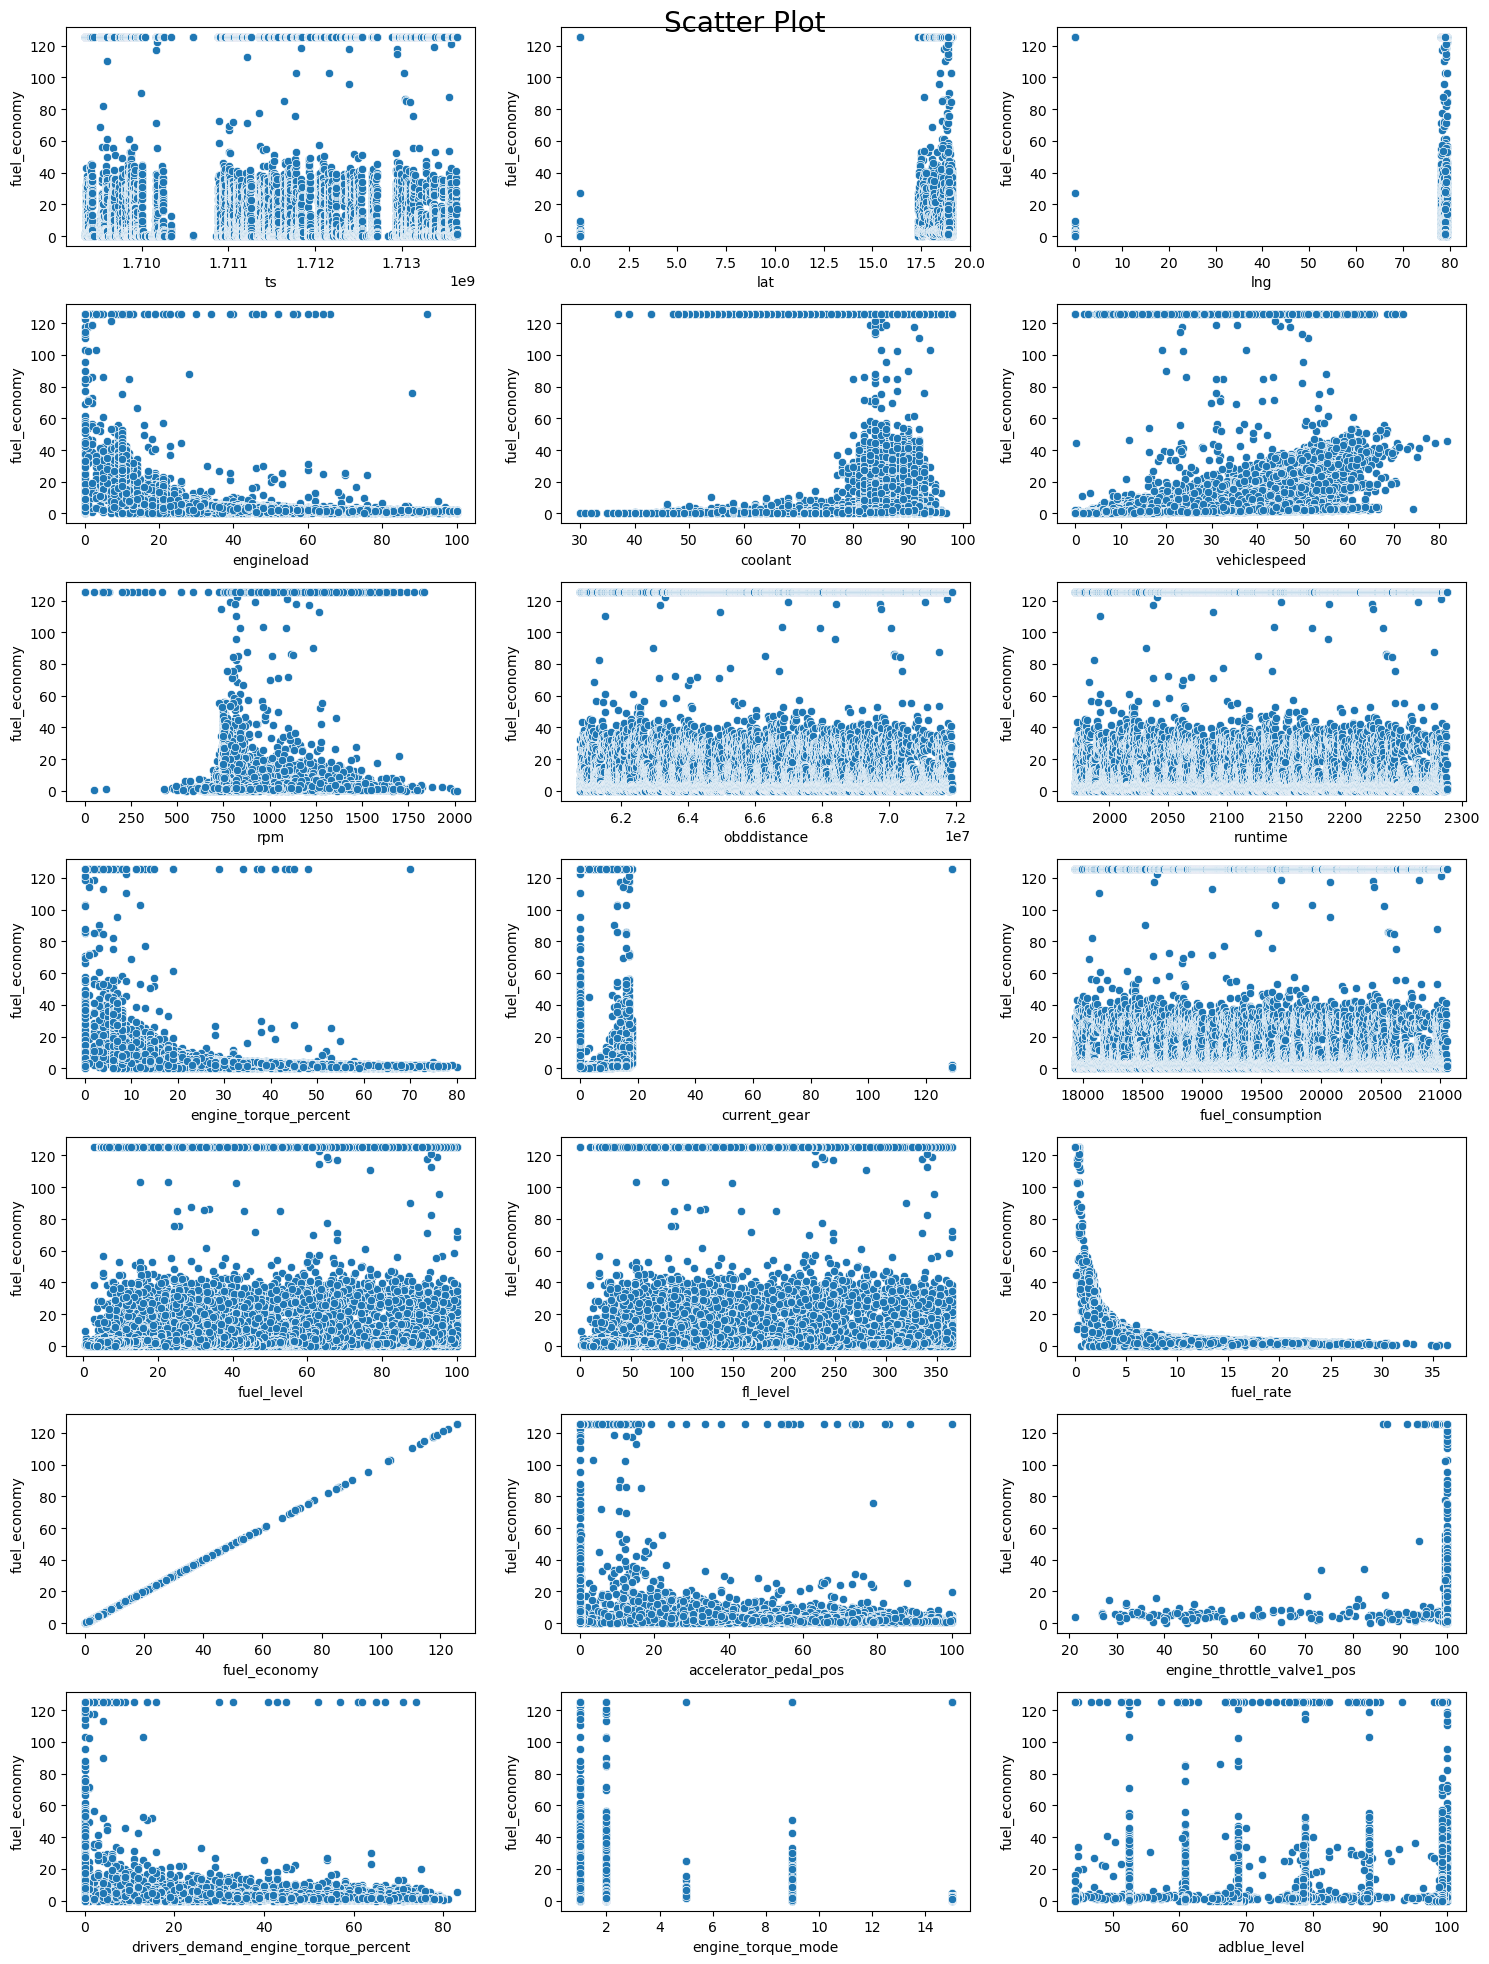

In [49]:
#plotting scatter plot to see the relationship between numerical features and target
#targeted feature is "fuel_economy"
#this is to check vehicle performance
#using whole cleaned dataframe

plt.figure(figsize=(15,20)) 
plt.suptitle('Scatter Plot', fontsize=20) 
for i in range(0, len(num)):
    plt.subplot(7,3,i+1)
    sns.scatterplot(y='fuel_economy',x=num[i], data=df_2)
    plt.tight_layout()

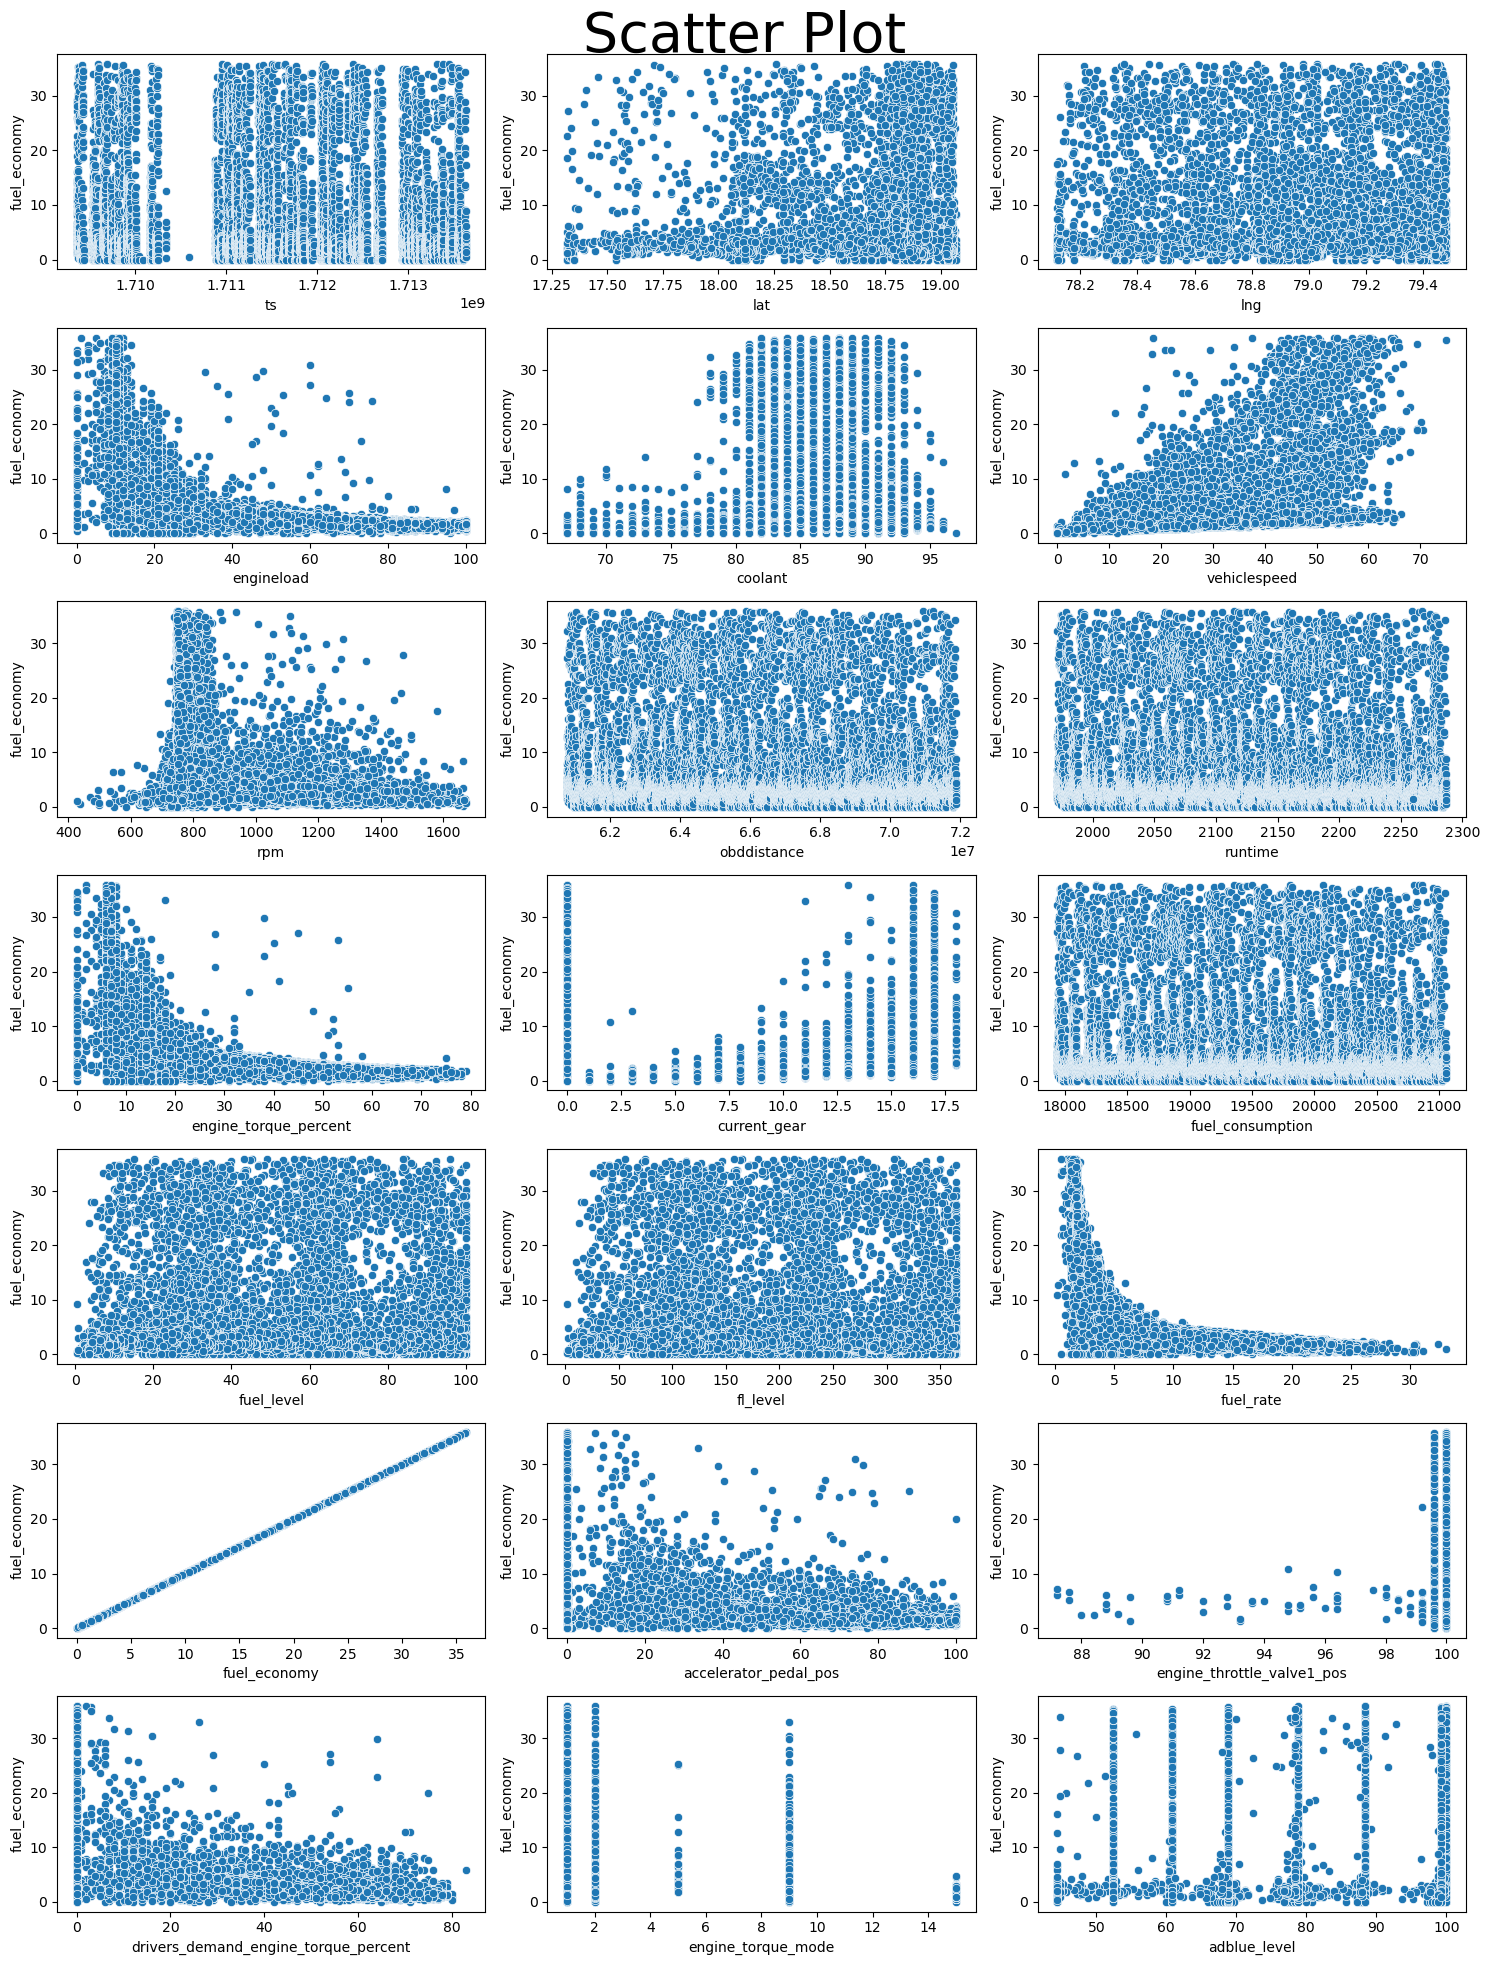

In [50]:
#using dataframe at cluster=1 

plt.figure(figsize=(15,20))
plt.suptitle('Scatter Plot', fontsize=40)
for i in range(0, len(num)):
    plt.subplot(7,3,i+1)
    sns.scatterplot(y='fuel_economy',x=num[i], data=df_no_o)
    plt.tight_layout()

Observations-5:
1. fuel economy decreases as engine load increases, highest around 10-15
2. fuel economy increases as coolant increases, highest around 82-92
3. fuel economy increases as vehiclespeed increases, highest around 65-70
4. fuel economy is first increasing, highest around 800, then decreasing as rpm increases
5. fuel economy decreases as engine torque percent increases, highest around 5-10
6. fuel economy increases as current gear increases, highest around 16-17
7. fuel rate decreases as fuel economy increases
8. fuel economy decreases as accelerator pedal position increases
9. fuel economy is highest when engine throttle valve2 position is near 100
10. fuel econmoy decreases as drivers demand for engine torque percent increases, highest at 0
11. fuel economy has higher values at 3 modes of engine torque, at 1,2 and 9

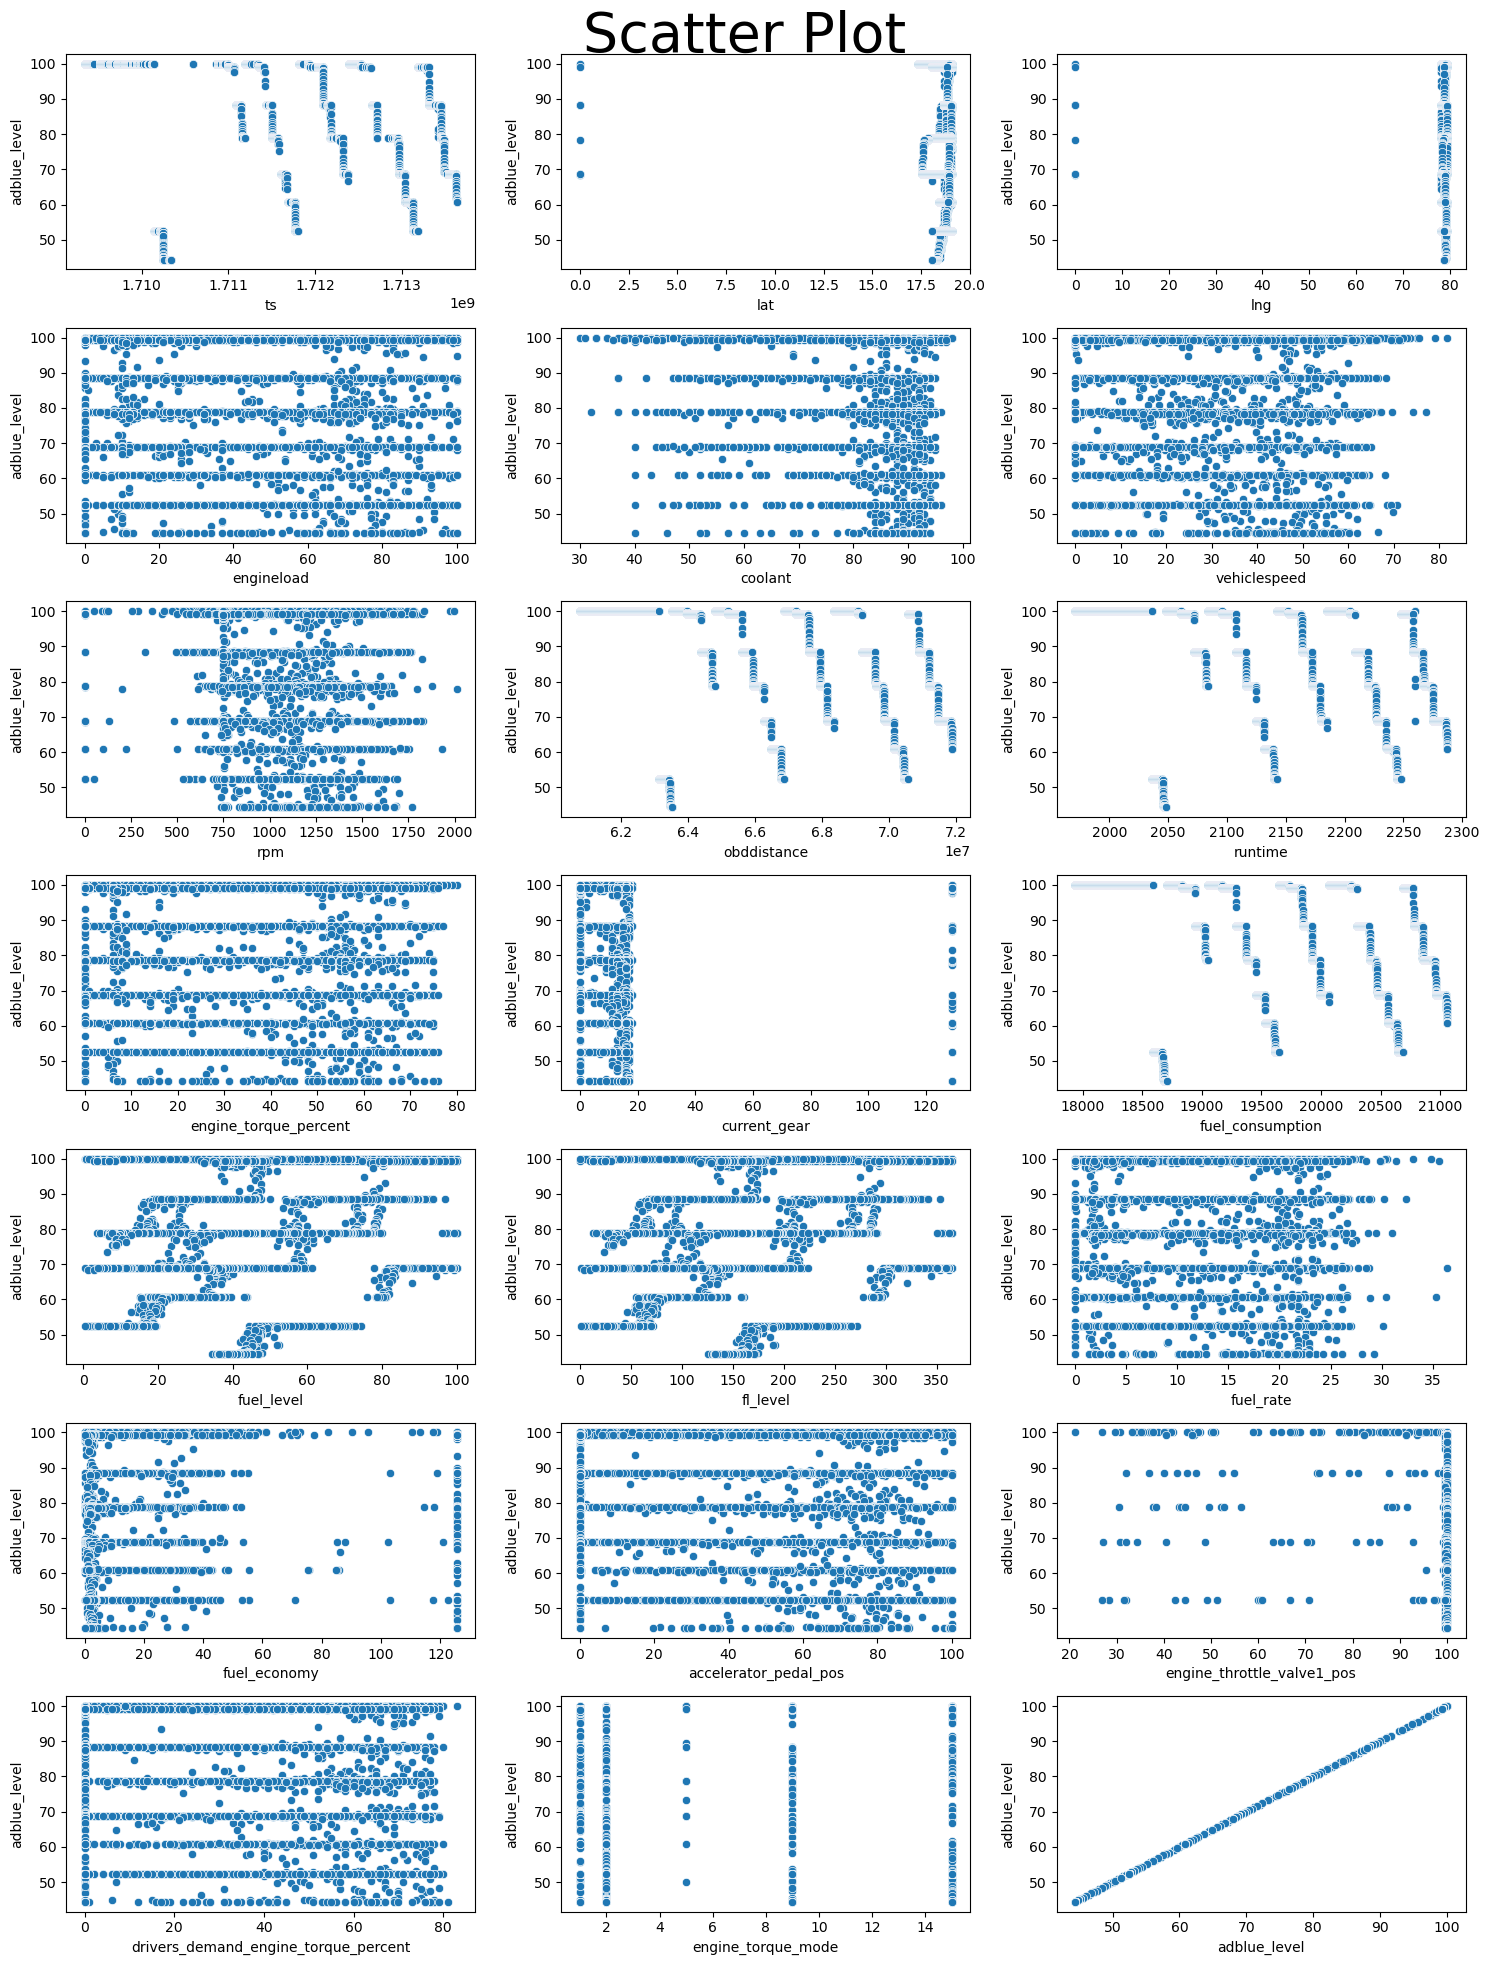

In [52]:
#plotting scatter plot to see the relationship between numerical features and target
#targeted feature is "adblue_level"
#this is to check safety or emissions
#using whole cleaned dataframe


plt.figure(figsize=(15,20))
plt.suptitle('Scatter Plot', fontsize=40)
for i in range(0, len(num)):
    plt.subplot(7,3,i+1)
    sns.scatterplot(y='adblue_level',x=num[i], data=df_2)
    plt.tight_layout()

Observations-6:
1. adblue level is considerably at higher levels when coolent is below 40
2. adblue level is considerably at higher levels when obd distance is below 6.3
3. adblue level is considerably at higher levels when fuel level is higher than 80
4. adblue level is considerably at higher levels when fuel economy is around 60-120

In [54]:
df_6=df_2.where(df_2['Cluster']==0).dropna()
del df_6['Cluster'] 

In [55]:
from scipy.stats import zscore
z_scores = df_6.apply(zscore)
df_no_o1 = df_6[(z_scores.abs() < 3).all(axis=1)]

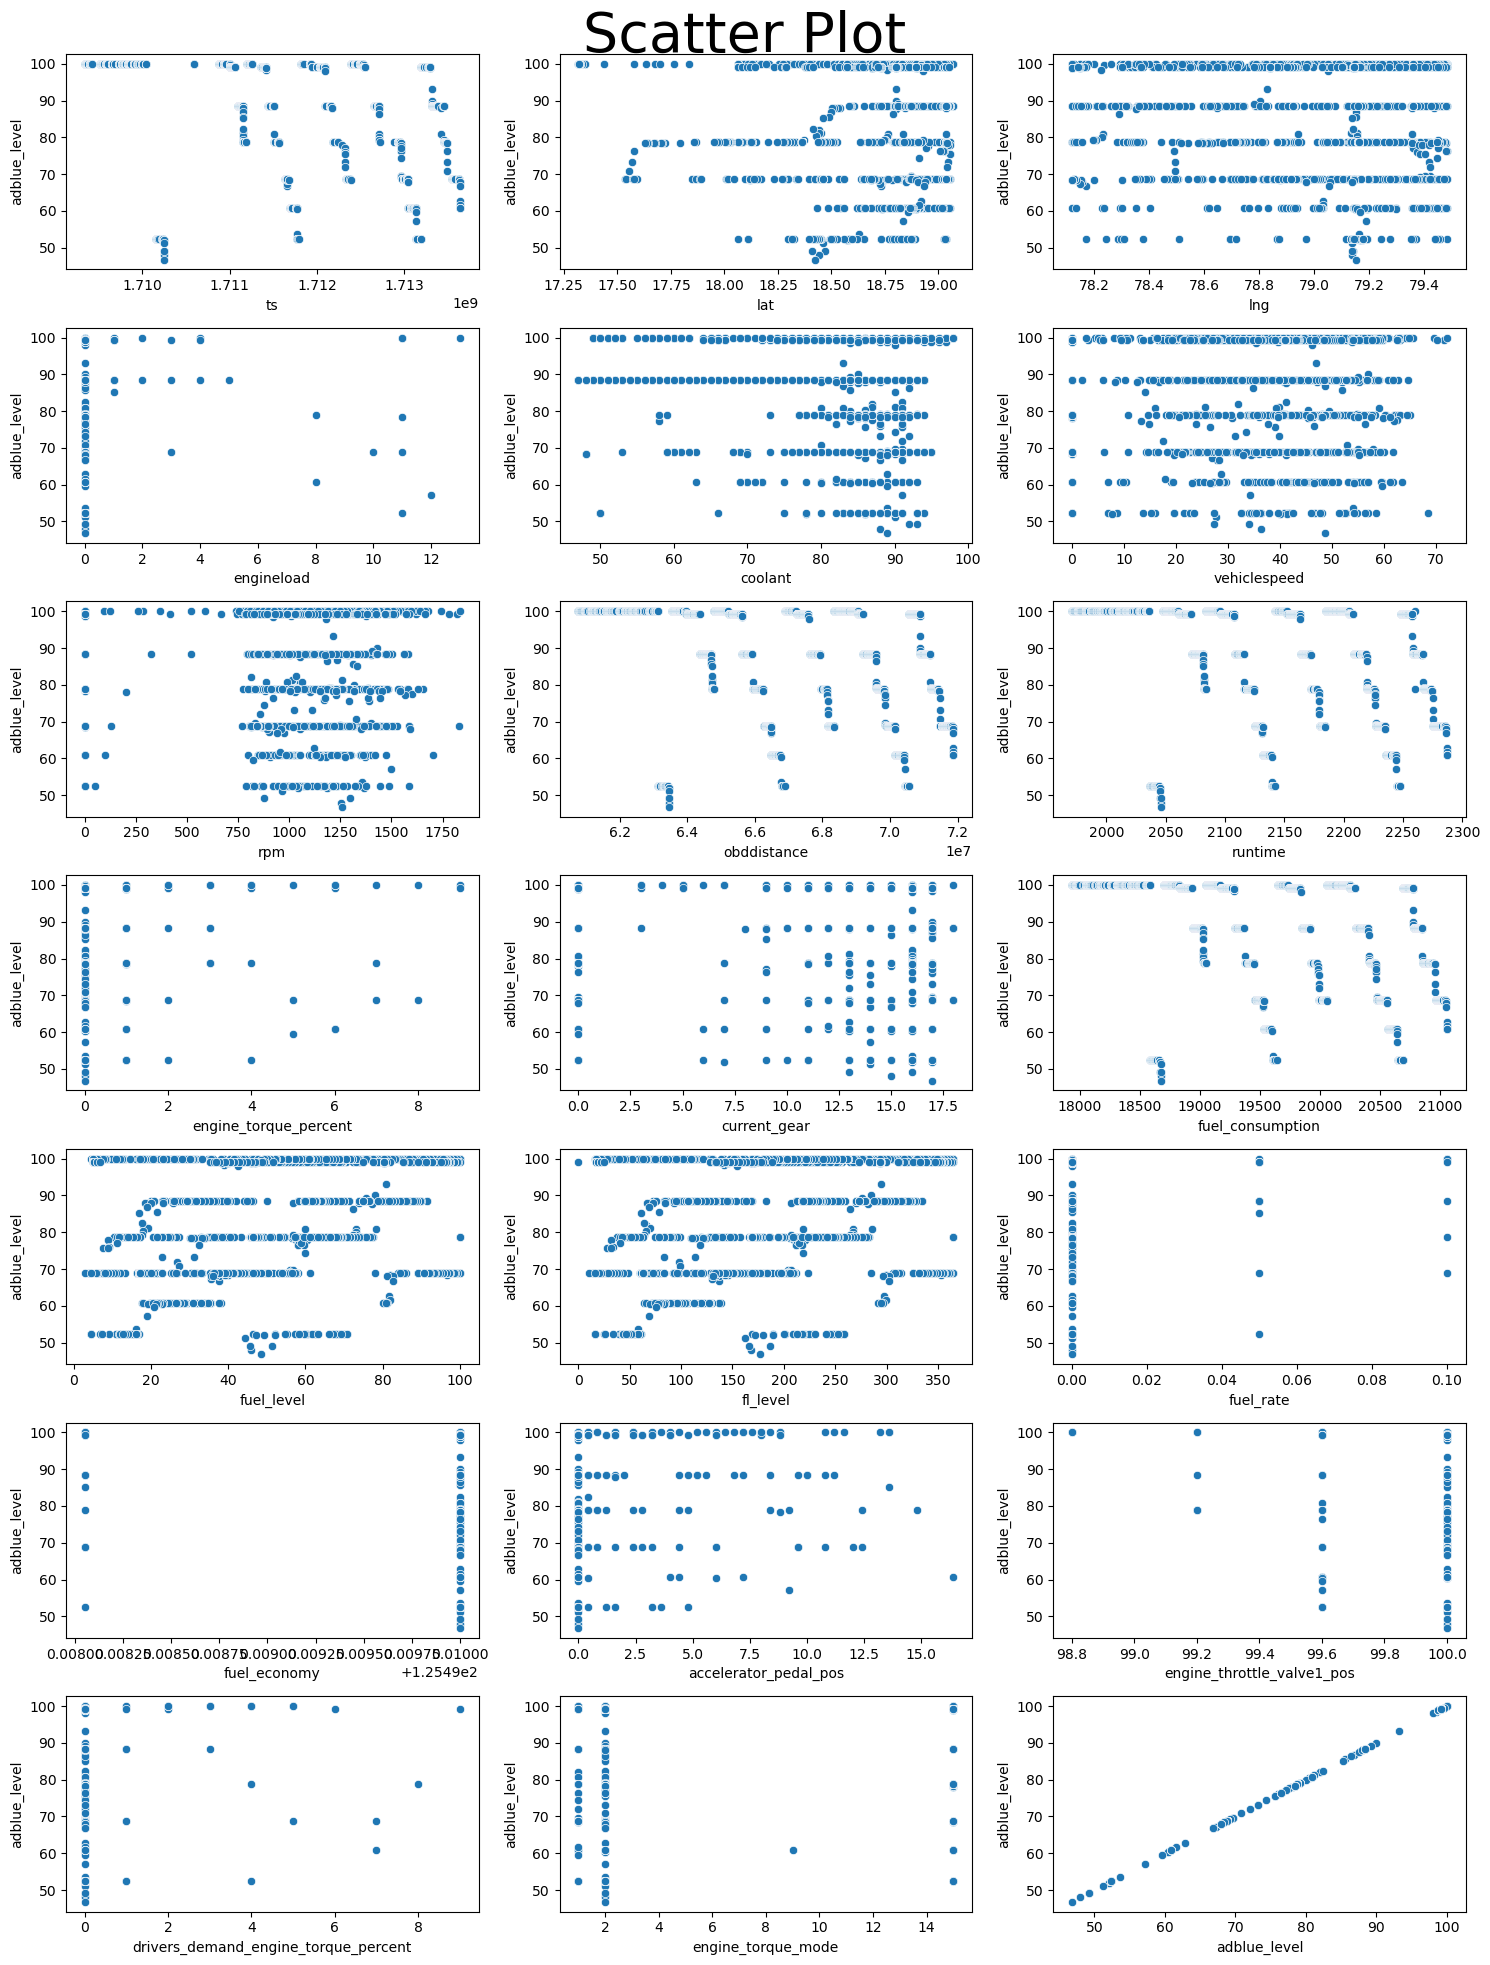

In [56]:
#using dataframe at cluster=0

plt.figure(figsize=(15,20))
plt.suptitle('Scatter Plot', fontsize=40)
for i in range(0, len(num)):
    plt.subplot(7,3,i+1)
    sns.scatterplot(y='adblue_level',x=num[i], data=df_no_o1)
    plt.tight_layout()

Observations-7:
1. adblue level is considerably at higher levels when rpm is between 50-750

COLLECTED OBSERVATIONS:

Observations-1:
1. runtime, fuel_consumption and obddistance has similar graphs and can be combined to form a new single feature mileage which is similar to fuel_economy.
2. drivers_demand_engine_torque_percent and accelerator_pedal_pos has similar graphs and can be combined to form a new feature driver_input_demand
3. fuel_level and fl_level are same thing and one can be omitted
4. engine_torque_percent and engineload has similar graphs and can be combined to form a new feature performance_demand

Observations-2:
1. brake_switch_status is mostly released
2. clutch_switch_status is mostly pressed
3. parking_switch_status is mostly released

Observations-3:

The graph shows there are 2 groups of data, so we need to separate them into 2 groups and then analyse

Observa-4s-4on:
1. Now we find a relation between vehicle speed and fuel economy.
2. As we increase speed, the fuel economy also increases until speed of 70km/h.

Inference:
1. At a speed of 65-70km/h the performance of vehicle is at the highest

Observat-5-5n. 1. 

fuel economy decreases as engine load increases, highest aroun02. 2. -15
fuel economy increases as coolant increases, highest aro 83. 3. 2-92
fuel economy increases as vehiclespeed increases, highest und 4. 4. 65-70
fuel economy is first increasing, highest around 800, then decreasing as  inc5. 5. reases
fuel economy decreases as engine torque percent increases, high arou6. 6. nd 5-10
fuel economy increases as current gear increases, higt arou7. 7. nd 16-17
fuel rate decreases as fuel economy 8. 8. increases
fuel economy decreases as accelerator ped osition9. 9.  increases
fuel economy is highest when engine th1ottle valvosition 10. 10. is near 100
fuel econmoy decreases as drivers demand for engine torque percenhighest at t. 11. highest at 0
fuel economy has higher values at 3 modes of engine torqueat  and 9-6

O-61. 1. bservations:

adblue level is considerably at higher levewhen coolen2. 2. t is below 40
adblue level is considerably at higher levels whe d distance3. 3.  is below 6.3
adblue level is considerably at higher levels when f level is h4. 4. igher than 80
adblue level is considerably at higher levels when fuel economy isrou60-120-7

O-71. 1. bservations:

adblue level is considerably at higher levels when rpm is between 50-750

CONCLUSIONS AND RECOMMENDATIONS:

Conclusion-1: Feature Engineering and Redundancy
1. Combining Similar Features:
--runtime, fuel_consumption, and obddistance have similar graphs and can be combined into a new feature mileage, representing vehicle efficiency.
--drivers_demand_engine_torque_percent and accelerator_pedal_pos can be merged into driver_input_demand to simplify the representation of driver control.
--engine_torque_percent and engine_load can be merged into performance_demand to represent overall engine workload.
2. Removing Redundant Features:
--As fuel_level and fl_level are almost identical, one of them should be omitted to avoid redundancy.

Conclusion-2: Switch Status Insights
--Given their static nature, these switch statuses might not provide significant variation for predictive models. Consider their relevance in analysis or discard if unimpactful.

Conclusion-3: Clustering for Segmentation
--The data exhibits two distinct groups, indicating potential clusters. These groups could correspond to different vehicle operating conditions or driver behaviors.

Conclusion-4: Speed and Fuel Economy Relationship
--Optimize driving strategies and algorithms to maintain speeds within the range of 65-70 km/h for enhanced fuel efficiency and performance.

Conclusion-5: Factors Influencing Fuel Economy that in turn tells about vehicle performance
--Optimize vehicle operation around the identified high fuel economy ranges and minimize conditions leading to decreased efficiency.

Conclusion-6: AdBlue Level Analysis
--Monitor and control AdBlue levels under these conditions to maintain emission standards and system efficiency.

Conclusion-7: RPM and AdBlue Levels
--Investigate why AdBlue consumption is higher at low RPM and explore strategies to optimize its use and reduce harmful emissions
